Jacobi iterations: 3270
Gauss-Seidel iterations: 1793
SOR iterations: 233


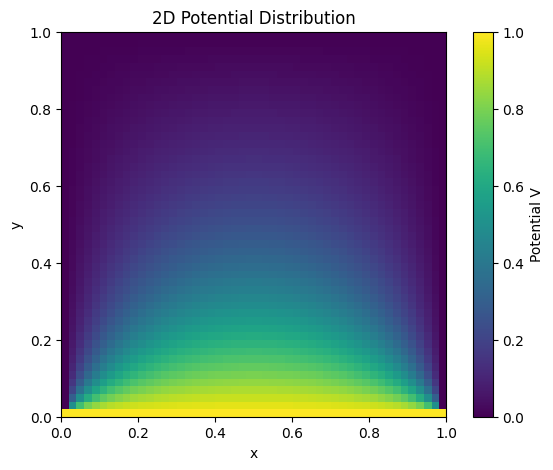

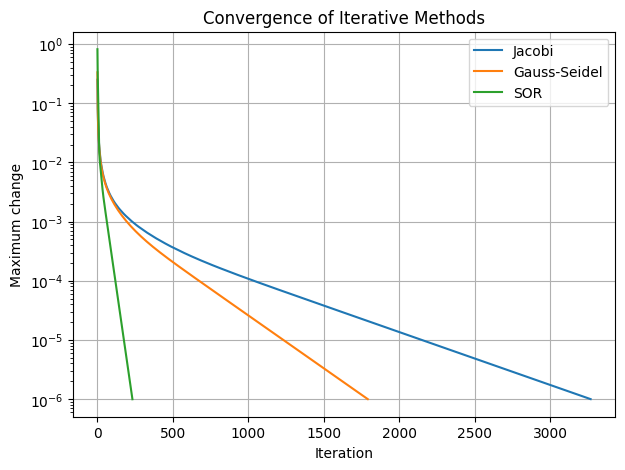

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 50
tol = 1e-6
max_iter = 10000

V_jacobi = np.zeros((N, N))
V_gs = np.zeros((N, N))
V_sor = np.zeros((N, N))

# Boundary conditions
V_jacobi[0, :] = 1
V_gs[0, :] = 1
V_sor[0, :] = 1


def jacobi(V):

    errors = []

    for n in range(max_iter):

        V_new = V.copy()

        V_new[1:-1, 1:-1] = (
            V[2:, 1:-1]
            + V[:-2, 1:-1]
            + V[1:-1, 2:]
            + V[1:-1, :-2]
        ) / 4

        error = np.max(np.abs(V_new - V))
        errors.append(error)

        V = V_new

        if error < tol:
            break

    return V, errors


def gauss_seidel(V):

    errors = []

    for n in range(max_iter):

        old = V.copy()

        for i in range(1, N - 1):
            for j in range(1, N - 1):

                V[i, j] = (
                    V[i+1, j]
                    + V[i-1, j]
                    + V[i, j+1]
                    + V[i, j-1]
                ) / 4

        error = np.max(np.abs(V - old))
        errors.append(error)

        if error < tol:
            break

    return V, errors


def sor(V, omega):

    errors = []

    for n in range(max_iter):

        old = V.copy()

        for i in range(1, N - 1):
            for j in range(1, N - 1):

                new_value = (
                    V[i+1, j]
                    + V[i-1, j]
                    + V[i, j+1]
                    + V[i, j-1]
                ) / 4

                V[i, j] = (
                    (1 - omega) * V[i, j]
                    + omega * new_value
                )

        error = np.max(np.abs(V - old))
        errors.append(error)

        if error < tol:
            break

    return V, errors


V_jacobi, error_jacobi = jacobi(V_jacobi)

V_gs, error_gs = gauss_seidel(V_gs)

omega = 1.8

V_sor, error_sor = sor(V_sor, omega)


print("Jacobi iterations:", len(error_jacobi))
print("Gauss-Seidel iterations:", len(error_gs))
print("SOR iterations:", len(error_sor))


plt.figure(figsize=(7, 5))

plt.imshow(
    V_sor,
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)

plt.colorbar(label="Potential V")

plt.xlabel("x")
plt.ylabel("y")

plt.title("2D Potential Distribution")

plt.show()


plt.figure(figsize=(7, 5))

plt.semilogy(
    error_jacobi,
    label="Jacobi"
)

plt.semilogy(
    error_gs,
    label="Gauss-Seidel"
)

plt.semilogy(
    error_sor,
    label="SOR"
)

plt.xlabel("Iteration")
plt.ylabel("Maximum change")

plt.title("Convergence of Iterative Methods")

plt.legend()
plt.grid()

plt.show()